# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Sadia Fatima

**Roll Number:** 023-24-0213

**GitHub Repository:** https://github.com/Sadia-Farooque/Machine_Learning

**Duration:** 3 Hours (independent, hands-on)

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")
print("Dataset loaded ")

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
Customer churn refers to customers deciding to stop using a telecommunications company's services and move to another provider. The goal is to identify customers who may leave in the future so the company can take preventive actions and improve customer retention. The most likely target variable is Churn, which indicates whether a customer has left (Yes) or stayed (No).

**Answer 2:**
* **5 Useful Predictors:**
  Contract: Customers with month-to-month plans have greater flexibility to leave, so they are generally more likely to churn than customers with longer contracts.
tenure: Customers who have been with the company for a shorter period may have weaker loyalty and therefore a greater possibility of leaving.
InternetService: The type of internet service can influence churn because some services, such as fiber optic, may be more expensive and affect customer satisfaction.
MonthlyCharges: Customers paying higher monthly fees may be more likely to reconsider their service if they feel they are not receiving enough value.
TechSupport: Customers without technical support may experience unresolved service problems, which can negatively affect their overall satisfaction.
* **2 Useless Predictors:**
  customerID: This is simply a unique identifier for each customer and does not provide meaningful information about their likelihood of leaving.
gender: Gender is not directly related to a customer's usage, satisfaction, or contract behavior, making it unlikely to provide useful predictive information.

**Answer 3:**
Are customers with month-to-month contracts more likely to leave than those who have one-year or two-year contracts?
Among customers with expensive Fiber Optic plans, is the churn rate lower for those who use Tech Support?

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [ ]:
# Task 4 — dataset shape, column names, data types
print("Dataset Shape (Rows, Columns):", df.shape)
print("\n Columns & Data Types ")
df.info()

# Separate numerical and categorical columns (updated for future Pandas compatibility)
num_cols = df.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("\nNumerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Dataset Shape (Rows, Columns): (7043, 21)

--- Columns & Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-n

In [3]:
# Task 5 — identify identifier columns / wrong data types
print("Identifier Column:", [col for col in df.columns if 'ID' in col])
print("TotalCharges raw data type:", df['TotalCharges'].dtype)
print("Sample TotalCharges values:", df['TotalCharges'].head())

Identifier Column: ['customerID']
TotalCharges raw data type: str
Sample TotalCharges values: 0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str


In [4]:
# Task 6 — unique values in 3 categorical columns
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f"Unique values in '{col}':\n{df[col].unique()}\n")

Unique values in 'Contract':
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Unique values in 'InternetService':
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Unique values in 'PaymentMethod':
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str



**Observations (Part 2):**
* **Dataset Scope:** 7,043 customer records across 21 columns (20 features + 1 target).
* **Numerical Features:** `tenure`, `MonthlyCharges`, `SeniorCitizen` (binary integer 0/1).
* **Categorical Features:** `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `TotalCharges`, `Churn`.
* **Identifier Column:** `customerID` is a primary key string and carries no predictive value.
* **Data Type Mismatch:** `TotalCharges` is stored as an `object` (string) instead of `float64` due to blank space strings (`" "`).

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [5]:
# Task 7 — missing values: count and percentage per column
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': null_counts, 'Percentage (%)': null_pct})
print(missing_summary)

                  Missing Count  Percentage (%)
customerID                    0             0.0
gender                        0             0.0
SeniorCitizen                 0             0.0
Partner                       0             0.0
Dependents                    0             0.0
tenure                        0             0.0
PhoneService                  0             0.0
MultipleLines                 0             0.0
InternetService               0             0.0
OnlineSecurity                0             0.0
OnlineBackup                  0             0.0
DeviceProtection              0             0.0
TechSupport                   0             0.0
StreamingTV                   0             0.0
StreamingMovies               0             0.0
Contract                      0             0.0
PaperlessBilling              0             0.0
PaymentMethod                 0             0.0
MonthlyCharges                0             0.0
TotalCharges                  0         

In [6]:
# Task 8 — duplicate rows vs duplicate IDs
print("Duplicate Rows Count:", df.duplicated().sum())
print("Duplicate customerID Count:", df['customerID'].duplicated().sum())

Duplicate Rows Count: 0
Duplicate customerID Count: 0


In [7]:
# Task 9 — investigate a suspicious / invalid value
whitespace_tc = (df['TotalCharges'] == ' ').sum()
print(f"Count of empty whitespace strings in TotalCharges: {whitespace_tc}")

# Inspect rows where TotalCharges is ' '
df[df['TotalCharges'] == ' '][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Count of empty whitespace strings in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Answer 7 (which missing-value problems need action, and why):**
The isnull().sum() check does not identify any missing values in the dataset. However, TotalCharges has 11 entries containing blank spaces (" ") instead of actual values. These need to be handled because they cause the column to be recognized as text rather than numeric data, which can create problems during calculations and machine learning.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
These are two separate data-quality problems. Duplicate rows occur when the complete records of two or more customers are exactly the same, whereas duplicate customerID values indicate that the same identifier has been assigned to multiple records. In this dataset, both types of duplicates are absent, with a count of 0 for each.

**Answer 9 (suspicious value found and how):**
The df.dtypes check showed that TotalCharges had an object data type instead of a numeric type. Further inspection using (df['TotalCharges'] == ' ').sum() identified 11 records containing whitespace blanks. After examining those records, it was found that each of them had tenure = 0, suggesting that these were newly registered customers who had not yet gone through a billing cycle.

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text string | Convert column to `float64` | `pd.to_numeric(df['TotalCharges'], errors='coerce')` | Required for numerical analysis and machine learning models. |
| 11 missing values in `TotalCharges` | Impute missing entries with `0.0` | `df['TotalCharges'].fillna(0.0)` | Customers have `tenure = 0`, so their total cumulative bill to date is $0.0. |
| `customerID` non-predictive column | Drop column | `df.drop(columns=['customerID'])` | Unique primary keys add random noise and introduce overfitting risks. |

In [8]:
# Task 11 — apply your cleaning decisions here
clean_df = df.copy()

# 1. Convert TotalCharges to numeric and handle whitespace missing values
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0.0)

# 2. Drop unique identifier column
if 'customerID' in clean_df.columns:
    clean_df = clean_df.drop(columns=['customerID'])

In [9]:
# Task 11 (continued) — confirm each issue is resolved
print("TotalCharges Data Type:", clean_df['TotalCharges'].dtype)
print("Remaining Missing Values in TotalCharges:", clean_df['TotalCharges'].isnull().sum())
print("Total Missing Values in clean_df:", clean_df.isnull().sum().sum())
print("Total Duplicate Rows in clean_df:", clean_df.duplicated().sum())
print("Cleaned DataFrame Shape:", clean_df.shape)

TotalCharges Data Type: float64
Remaining Missing Values in TotalCharges: 0
Total Missing Values in clean_df: 0
Total Duplicate Rows in clean_df: 22
Cleaned DataFrame Shape: (7043, 20)


## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

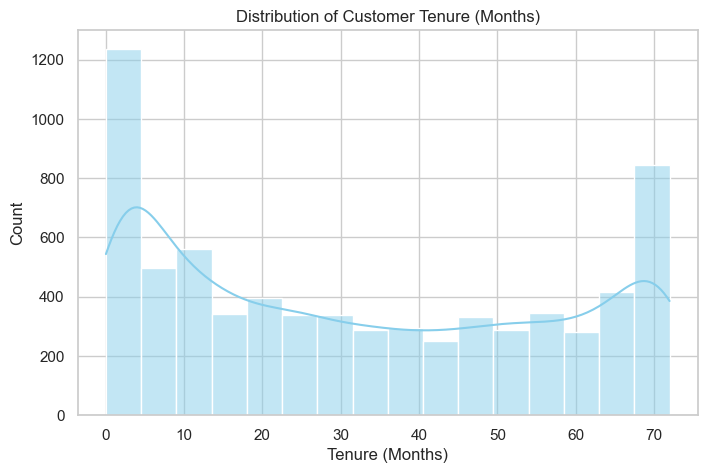

In [10]:
# Task 12 — numerical feature 1: distribution plot
sns.histplot(clean_df['tenure'], kde=True, color='skyblue')
plt.title('Distribution of Customer Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.show()

**Observation:** Customer tenure shows a clear bimodal pattern, with large numbers of customers concentrated around 1 month and 72 months. This suggests the dataset contains both many newly acquired customers and a significant group of long-term, loyal subscribers.

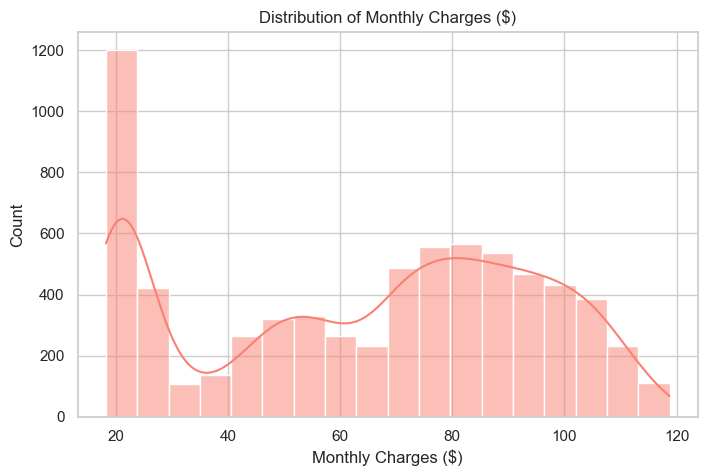

In [11]:
# Task 12 — numerical feature 2: distribution plot
sns.histplot(clean_df['MonthlyCharges'], kde=True, color='salmon')
plt.title('Distribution of Monthly Charges ($)')
plt.xlabel('Monthly Charges ($)')
plt.show()

**Observation:** MonthlyCharges has a noticeable peak around $20, which mainly reflects customers on basic phone-only plans. There is also a broader concentration between $70 and $110, likely representing customers subscribed to internet and bundled service packages.

In [ ]:
# Task 12 — categorical feature 1: distribution plot
sns.countplot(data=clean_df, x='Contract', palette='Set2')
plt.title('Frequency of Contract Types')
plt.xlabel('Contract Type')
plt.show()

**Observation:** Over 50% of subscribers are on a Month-to-month contract, while One-year and Two-year commitments represent significantly smaller customer portions.

In [ ]:
# Task 13 — categorical feature 2: distribution plot
sns.countplot(data=clean_df, x='InternetService', palette='Set2')
plt.title('Distribution of Internet Service Types')
plt.xlabel('Internet Service Provider')
plt.show()

**Observation:** Fiber Optic has the highest number of subscribers, with DSL being the next most common option. A smaller portion of customers do not use an internet service..

**Answer 13 (outliers / skew and possible explanation):**
TotalCharges is noticeably right-skewed, mainly because customers who have stayed longer naturally accumulate higher total charges. The variables tenure and MonthlyCharges do not show any major extreme values outside their expected business ranges.

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [ ]:
# Task 14 — churn counts and percentages
churn_counts = clean_df['Churn'].value_counts()
churn_pct = clean_df['Churn'].value_counts(normalize=True) * 100

print("--- Target Class Distribution ---")
print(f"Non-Churned (No):  {churn_counts['No']} ({churn_pct['No']:.2f}%)")
print(f"Churned (Yes):      {churn_counts['Yes']} ({churn_pct['Yes']:.2f}%)")

sns.countplot(data=clean_df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Target Variable Distribution (Churn)')
plt.show()

**Answer 14 (balanced or imbalanced?):**
The target variable is imbalanced, as the majority of customers remain with the company. Around 73.46% of customers are classified as No churn, whereas only 26.54% are classified as Yes churn.

**Answer 15 (why imbalance might matter later):**
Class imbalance can cause a machine learning model to favor the majority class (No) because doing so can produce a high overall accuracy. For example, a model could achieve more than 73% accuracy by predicting that every customer will stay, while still failing to identify the customers who are actually likely to churn.

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

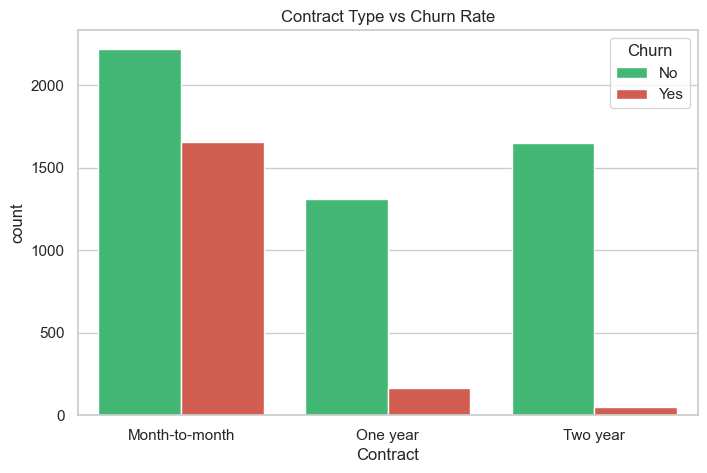

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [15]:
# Task 16 — categorical feature 1 vs Churn
sns.countplot(data=clean_df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Contract Type vs Churn Rate')
plt.show()

print(pd.crosstab(clean_df['Contract'], clean_df['Churn'], normalize='index') * 100)

**Observation:** : Customers on month-to-month contracts have a significantly higher churn rate than customers committed to longer-term contracts.
**Evidence:** The pd.crosstab analysis shows that 42.71% of month-to-month customers churn, compared with only 2.83% of customers on two-year contracts.
**Possible Explanation:** Month-to-month subscribers have fewer restrictions and can switch providers more easily because they are not tied to a long-term agreement or significant cancellation commitments.

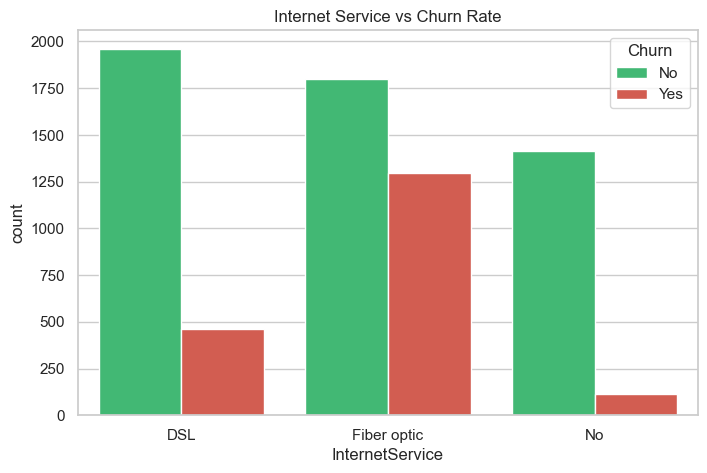

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [16]:
# Task 16 — categorical feature 2 vs Churn
sns.countplot(data=clean_df, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Internet Service vs Churn Rate')
plt.show()

print(pd.crosstab(clean_df['InternetService'], clean_df['Churn'], normalize='index') * 100)

**Observation:** Customers using Fiber Optic internet have a considerably higher churn rate compared with those using DSL or those without internet service.
**Evidence:** The analysis indicates that 41.89% of Fiber Optic customers churned, while the churn rate among DSL customers was 18.96%.
**Possible Explanation:** : Fiber Optic plans are generally more expensive, so customers may be more likely to leave if they feel the service is not worth the cost or if they experience service-related issues.

In [ ]:
# Task 17 — numerical feature 1 vs Churn
sns.boxplot(data=clean_df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure Distribution by Churn Status')
plt.show()

print(clean_df.groupby('Churn')['tenure'].describe())

**Observation:** Customers who churn tend to have much shorter tenures compared with customers who remain with the company.
**Evidence:** The median tenure for churned customers is 10 months, while customers who stayed have a median tenure of 38 months.
**Possible Explanation:** Customers are more likely to leave during the early stages of their relationship with the company. Those who remain for a longer period may develop stronger loyalty and become less likely to switch providers.

In [ ]:
# Task 17 — numerical feature 2 vs Churn
sns.boxplot(data=clean_df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

print(clean_df.groupby('Churn')['MonthlyCharges'].describe())

**Observation:** Customers with higher monthly charges appear to be more likely to churn than those with lower monthly bills.
**Evidence:** The median MonthlyCharges for churned customers is $79.65, compared with $64.43 for customers who remained.
**Possible Explanation:** Higher recurring charges may make customers more price-sensitive and encourage them to look for cheaper alternatives from competing providers.

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

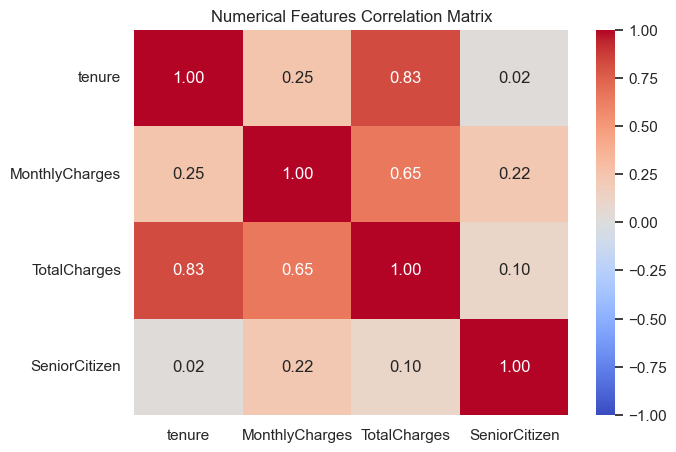

In [19]:
# Task 18 — correlation matrix and heatmap
plt.figure(figsize=(7, 5))
num_vars = clean_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
sns.heatmap(num_vars.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numerical Features Correlation Matrix')
plt.show()

**Answer 18 (most correlated pairs):**
The highest correlation is observed between tenure and TotalCharges, with r = 0.83. The second strongest relationship is between MonthlyCharges and TotalCharges, with r = 0.65.

**Answer 19 (correlation vs. causation; potential problems):**
A strong correlation between these variables does not necessarily mean that one directly causes the other. In this case, TotalCharges is naturally influenced by both tenure and MonthlyCharges because longer subscriptions and higher monthly bills lead to greater total charges. Using highly related variables such as tenure and TotalCharges together may create multicollinearity, which can make coefficient estimates less stable in linear models.

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
customerID should be excluded because it is only a unique identifier and does not provide meaningful information for predicting churn. The dataset also does not appear to contain any post-churn information, such as CancellationReason or ExitSurveyScore, that could cause data leakage.

**Answer 21 (what would go wrong):**
Keeping irrelevant ID columns or features containing information from after the customer has already churned can mislead the model. The model may learn meaningless patterns from customer IDs or use information that would not be available when making a real prediction, resulting in misleadingly high validation performance and poor results on new customers.

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | None | **Remove** | Unique primary key string; contains no predictive behavioral signal. |
| gender | Categorical | Feature | **Keep** | Baseline demographic attribute. |
| SeniorCitizen | Binary | Feature | **Keep** | Demographic attribute linked to fixed income and price sensitivity. |
| Partner | Categorical | Feature | **Keep** | Household status influences subscription retention. |
| Dependents | Categorical | Feature | **Keep** | Family structure affects household service stability. |
| tenure | Numerical | Feature | **Keep** | Strong inverse relationship with churn risk. |
| PhoneService | Categorical | Feature | **Keep** | Primary service indicator. |
| MultipleLines | Categorical | Feature | **Keep** | Multi-line add-on service tier. |
| InternetService | Categorical | Feature | **Keep** | Fiber Optic displays strong correlation with customer churn. |
| OnlineSecurity | Categorical | Feature | **Keep** | Security add-on that reduces customer churn rate. |
| OnlineBackup | Categorical | Feature | **Keep** | Data backup add-on service. |
| DeviceProtection | Categorical | Feature | **Keep** | Hardware protection add-on service. |
| TechSupport | Categorical | Feature | **Keep** | Technical support drastically improves customer retention. |
| StreamingTV | Categorical | Feature | **Keep** | Media add-on engagement feature. |
| StreamingMovies | Categorical | Feature | **Keep** | Media add-on engagement feature. |
| Contract | Categorical | Feature | **Keep** | Strongest structural predictor of customer churn. |
| PaperlessBilling | Categorical | Feature | **Keep** | Billing preference indicator. |
| PaymentMethod | Categorical | Feature | **Keep** | Electronic Check payment method correlates with high churn. |
| MonthlyCharges | Numerical | Feature | **Keep** | Primary economic driver for customer churn. |
| TotalCharges | Numerical | Feature | **Keep** | Cumulative billing magnitude (missing entries imputed with 0.0). |
| Churn | Categorical | Target | **Keep** | Target classification label. |

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [20]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Convert TotalCharges to float and impute tenure=0 missing entries
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0.0)

# Drop identifier column
if 'customerID' in clean_df.columns:
    clean_df = clean_df.drop(columns=['customerID'])

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Saved clean_df to 'clean_churn.csv' successfully!")

Saved clean_df to 'clean_churn.csv' successfully!


# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("--- clean_df Info ---")
clean_df.info()

print("\nMissing Values Count:", clean_df.isnull().sum().sum())
print("Duplicate Rows Count:", clean_df.duplicated().sum())

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

**Finding 1**
- Observation: Month-to-month customers show the highest churn rate by a significant margin.
- Evidence: About 42.71% of month-to-month customers churn, compared with only 2.83% of two-year contract customers.
- Interpretation: Encouraging customers to choose longer-term contracts could be an effective strategy for reducing churn.

**Finding 2**
- Observation: Fiber Optic users have a considerably higher churn rate than other internet-service groups
- Evidence: The churn rate is 41.89% for Fiber Optic customers, compared with 18.96% for DSL and 7.40% for customers without internet service.
- Interpretation: Higher costs or potential service-related dissatisfaction may be contributing to the increased churn among Fiber Optic users.

**Finding 3**
-Observation: A large portion of churn occurs relatively early in the customer's relationship with the company.
-Evidence: Churned customers have a median tenure of 10 months, while retained customers have a median tenure of 38 months.
-Interpretation: The first year appears to be an important period for customer retention efforts and early intervention.

**Finding 4**
-Observation: Customers using manual payment methods tend to have noticeably higher churn rates.
-Evidence: The churn rate for Electronic Check users is 45.29%, compared with approximately 15% among customers using automatic payment methods.
-Interpretation: Customers who manually manage their payments may be more aware of their recurring expenses, which could contribute to higher cancellation rates.

**Finding 5**
-Observation: Missing values can sometimes be hidden as text rather than being recognized as actual null values.
-Evidence: TotalCharges contained 11 blank-space values (" "), all associated with customers having tenure = 0.
-Interpretation: Proper data cleaning requires checking for hidden placeholders before converting columns to numerical data types.

---

**Task 26 — Final Reflection Questions**

1. **What was the most important data-quality issue you found?**
   The most important issue was the presence of blank spaces (" ") in TotalCharges. These values were not detected by the usual missing-value check and caused the column to be stored as an object instead of a numeric type.

2. **What was the most interesting pattern you discovered?**
   The most noticeable pattern was the difference in churn between payment methods. Electronic Check customers had a churn rate of around 45%, compared with roughly 15% for customers using automatic payment methods..

3. **Which feature seems most useful for predicting churn?**
   Contract appears to be one of the strongest predictors because the type and duration of a customer's contract are strongly associated with their likelihood of leaving.
4. **Which feature should probably not be used, and why?**
   customerID should be removed because it is simply a unique identifier and does not contain meaningful information about customer behavior. Keeping it could introduce irrelevant patterns and potentially cause overfitting.

5. **What preprocessing will be required before ML modeling (conceptually — do not implement it)?**
 The data will need several preprocessing steps, including handling missing values, converting categorical variables through techniques such as One-Hot Encoding, converting the target into binary values (Yes = 1, No = 0), scaling numerical features when required, and addressing the imbalance between churned and non-churned customers

6. **What would you do next if you had another 3 hours?**
  I would create additional features to capture relationships between variables, such as the relationship between MonthlyCharges and tenure. I would then build and compare churn models for different customer segments, such as high-value and low-value customers, to determine whether different groups require different retention strategies.

## Bonus Tasks 

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [21]:
# Bonus — optional exploration: Churn across Contract + InternetService
segmented_churn = pd.crosstab(
    [clean_df['Contract'], clean_df['InternetService']], 
    clean_df['Churn'], 
    normalize='index'
) * 100

print("--- Segmented Churn Rate (%) ---")
print(segmented_churn.round(2))

--- Segmented Churn Rate (%) ---
Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.53   2.47
Two year       DSL              98.09   1.91
               Fiber optic      92.77   7.23
               No               99.22   0.78
